## Imports

In [1]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, f1_score
from sklearn.calibration import CalibratedClassifierCV, calibration_curve

## Load test/train

In [2]:
train = pd.read_csv('train.csv')
test = pd.read_csv('test.csv')

print("Train:", train.shape, "Test:", test.shape)
train.head()

Train: (6241, 3) Test: (1759, 3)


,resume_text,job_description_text,label
0,SummaryHighly motivated Sales Associate with e...,Net2Source Inc. is an award-winning total work...,No Fit
1,Professional SummaryCurrently working with Cat...,At Salas OBrien we tell our clients that were ...,No Fit
2,SummaryI started my construction career in Jun...,Schweitzer Engineering Laboratories (SEL) Infr...,No Fit
3,SummaryCertified Electrical Foremanwith thirte...,"Mizick Miller & Company, Inc. is looking for a...",No Fit
4,SummaryWith extensive experience in business/r...,Life at Capgemini\nCapgemini supports all aspe...,No Fit


## EDA: label distribution

Train Label distribution:
label
No Fit           3143
Potential Fit    1556
Good Fit         1542
Name: count, dtype: int64

Test label distribution:
label
No Fit           857
Good Fit         458
Potential Fit    444
Name: count, dtype: int64


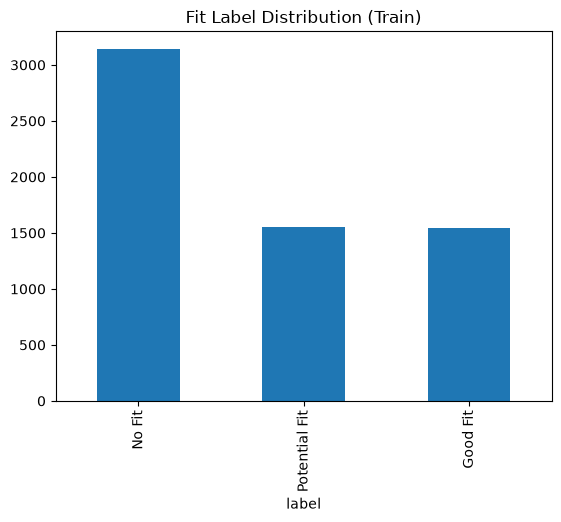

In [3]:
print('Train Label distribution:')
print(train['label'].value_counts())
print("\nTest label distribution:")
print(test['label'].value_counts())

train['label'].value_counts().plot(kind='bar')
plt.title('Fit Label Distribution (Train)')
plt.show()

## Text cleaning

In [4]:
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'http\S+|www\S+', ' ', text)
    text = re.sub(r'\S+@\S+', ' ', text)
    text = re.sub(r'[^a-z\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

train['resume_clean']=train['resume_text'].apply(clean_text)
train['jd_clean'] = train['job_description_text'].apply(clean_text)
test['resume_clean'] = test['resume_text'].apply(clean_text)
test['jd_clean'] = test['job_description_text'].apply(clean_text)

train[['resume_clean', 'jd_clean']].head(2)

,resume_clean,jd_clean
0,summaryhighly motivated sales associate with e...,net source inc is an award winning total workf...
1,professional summarycurrently working with cat...,at salas obrien we tell our clients that were ...


## Encode labels

In [5]:
le = LabelEncoder()
train['label_enc'] = le.fit_transform(train['label'])
test['label_enc'] = le.transform(test['label'])

print(dict(zip(le.classes_, le.transform(le.classes_))))

{'Good Fit': np.int64(0), 'No Fit': np.int64(1), 'Potential Fit': np.int64(2)}


## Fit TF-IDF jointly on resumes + JDs
### Fit on combined train text only (never on test) so both texts share one vocabulary/vector space

In [6]:
combined_train_text = pd.concat([train['resume_clean'], train['jd_clean']])

tfidf = TfidfVectorizer(max_features=5000, stop_words='english', ngram_range=(1, 2), min_df=2)
tfidf.fit(combined_train_text)

print("Vocabulary size:", len(tfidf.vocabulary_))

Vocabulary size: 5000


## Build features: cosine similarity + raw vectors
### Feature set: cosine similarity between resume and JD, plus each vector's norm/length as weak signals

In [ ]:

def build_features(df, tfidf):
    resume_vecs = tfidf.transform(df['resume_clean'])
    jd_vecs = tfidf.transform(df['jd_clean'])

    sims = np.array([
        cosine_similarity(resume_vecs[i], jd_vecs[i])[0, 0]
        for i in range(df.shape[0])
    ])

    resume_len = df['resume_clean'].str.split().str.len().values
    jd_len = df['jd_clean'].str.split().str.len().values

    features = np.column_stack([sims, resume_len, jd_len])
    return features

X_train = build_features(train, tfidf)
X_test = build_features(test, tfidf)
y_train = train['label_enc'].values
y_test = test['label_enc'].values

print(X_train.shape, X_test.shape)

(6241, 3) (1759, 3)


## Baseline matcher: Logistic Regression on similarity features

In [9]:
clf = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)

print(classification_report(y_test, y_pred, target_names=le.classes_))
print("Macro-F1:", f1_score(y_test, y_pred, average='macro'))

               precision    recall  f1-score   support

     Good Fit       0.33      0.40      0.36       458
       No Fit       0.56      0.58      0.57       857
Potential Fit       0.30      0.21      0.24       444

     accuracy                           0.44      1759
    macro avg       0.39      0.40      0.39      1759
 weighted avg       0.43      0.44      0.43      1759

Macro-F1: 0.39169513423153285


## Confusion matrix

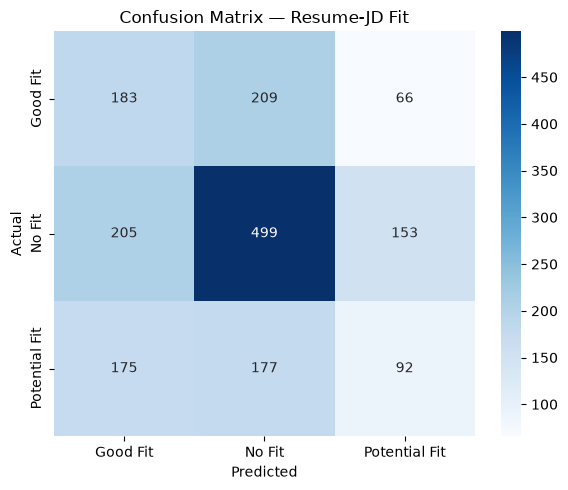

In [10]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix — Resume-JD Fit')
plt.tight_layout()
plt.show()

## Platt scaling calibration

In [11]:
calibrated_clf = CalibratedClassifierCV(clf, method='sigmoid', cv=3)
calibrated_clf.fit(X_train, y_train)
y_pred_calibrated = calibrated_clf.predict(X_test)
y_proba_calibrated = calibrated_clf.predict_proba(X_test)

print("Calibrated macro-F1:", f1_score(y_test, y_pred_calibrated, average='macro'))

Calibrated macro-F1: 0.2966243082963096


## Calibration curve, one-vs-rest for "Good Fit" class

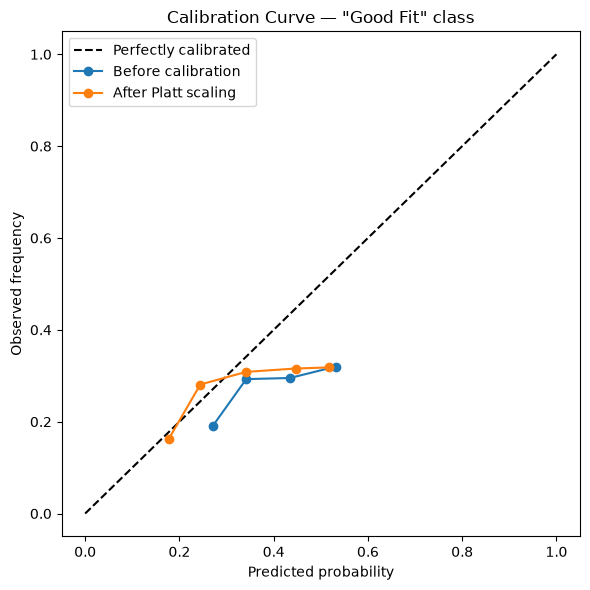

In [12]:
# CELL 11 — Calibration curve, one-vs-rest for "Good Fit" class (Eve)
good_fit_idx = list(le.classes_).index('Good Fit')  # adjust label string if it differs
y_test_binary = (y_test == good_fit_idx).astype(int)
y_proba_good_fit = y_proba_calibrated[:, good_fit_idx]

# Before calibration, for comparison
y_proba_raw = clf.predict_proba(X_test)[:, good_fit_idx]

prob_true_raw, prob_pred_raw = calibration_curve(y_test_binary, y_proba_raw, n_bins=10)
prob_true_cal, prob_pred_cal = calibration_curve(y_test_binary, y_proba_good_fit, n_bins=10)

plt.figure(figsize=(6, 6))
plt.plot([0, 1], [0, 1], 'k--', label='Perfectly calibrated')
plt.plot(prob_pred_raw, prob_true_raw, marker='o', label='Before calibration')
plt.plot(prob_pred_cal, prob_true_cal, marker='o', label='After Platt scaling')
plt.xlabel('Predicted probability')
plt.ylabel('Observed frequency')
plt.title('Calibration Curve — "Good Fit" class')
plt.legend()
plt.tight_layout()
plt.show()

In [19]:
import joblib
joblib.dump(clf, 'step2_matching_model.pkl')
joblib.dump(tfidf, 'step2_tfidf_vectorizer.pkl')
joblib.dump(le, 'step2_label_encoder.pkl')

['step2_label_encoder.pkl']